In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Google Colab is ready!")

Google Colab is ready!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving business.retailsales.csv to business.retailsales.csv


In [3]:
import pandas as pd

df = pd.read_csv("business.retailsales.csv")

In [4]:
df = pd.read_csv("/content/business.retailsales.csv")

In [5]:
df.head()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Art & Sculpture,34,14935.0,-594.00,-1609.0,12732.00
1,Basket,13,3744.0,-316.80,0.0,3427.20
2,Basket,12,3825.0,-201.60,-288.0,3335.40
3,Basket,17,3035.0,-63.25,0.0,2971.75
4,Art & Sculpture,47,2696.8,-44.16,0.0,2652.64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1775 entries, 0 to 1774
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Type     1767 non-null   object 
 1   Net Quantity     1775 non-null   int64  
 2   Gross Sales      1775 non-null   float64
 3   Discounts        1775 non-null   float64
 4   Returns          1775 non-null   float64
 5   Total Net Sales  1775 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 83.3+ KB


In [7]:
df.isnull().sum()

,0
Product Type,8
Net Quantity,0
Gross Sales,0
Discounts,0
Returns,0
Total Net Sales,0


In [8]:
df.describe()

,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
count,1775.000000,1775.000000,1775.000000,1775.000000,1775.000000
mean,3.712676,199.671746,-6.317623,-5.385437,187.968687
std,6.243078,464.880638,20.903517,46.654269,414.547039
min,-1.000000,0.000000,-594.000000,-1609.000000,-106.250000
25%,1.000000,48.000000,-6.000000,0.000000,44.800000
50%,2.000000,100.000000,0.000000,0.000000,96.000000
75%,4.000000,185.500000,0.000000,0.000000,184.750000
max,96.000000,14935.000000,0.000000,0.000000,12732.000000


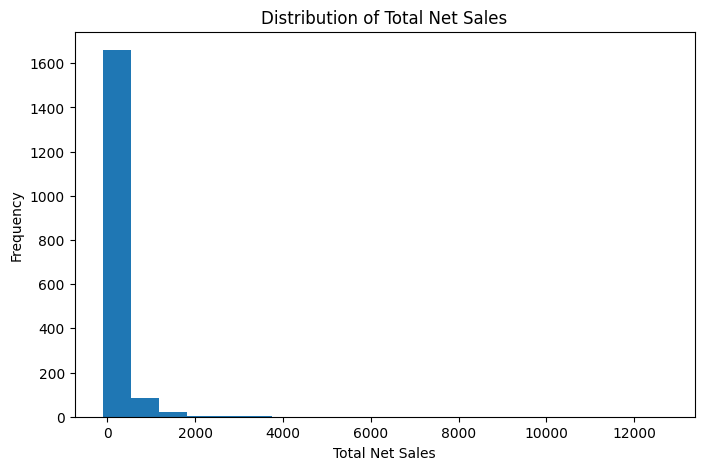

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Total Net Sales"], bins=20)
plt.title("Distribution of Total Net Sales")
plt.xlabel("Total Net Sales")
plt.ylabel("Frequency")
plt.show()

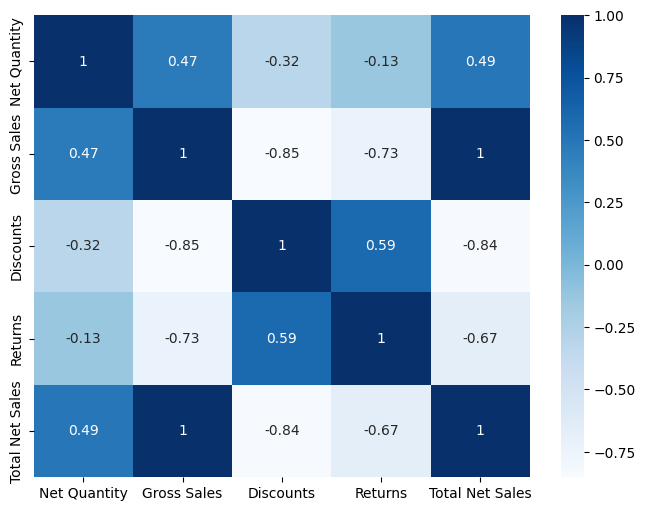

In [10]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Product Type"] = le.fit_transform(df["Product Type"])

In [12]:
df.head()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,1,34,14935.0,-594.00,-1609.0,12732.00
1,2,13,3744.0,-316.80,0.0,3427.20
2,2,12,3825.0,-201.60,-288.0,3335.40
3,2,17,3035.0,-63.25,0.0,2971.75
4,1,47,2696.8,-44.16,0.0,2652.64


In [13]:
X = df.drop("Total Net Sales", axis=1)
y = df["Total Net Sales"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,MAE,R2 Score
0,Linear Regression,1.034540e-13,1.000000
1,Decision Tree,3.841690e+00,0.993616
2,Random Forest,3.897222e+00,0.993391


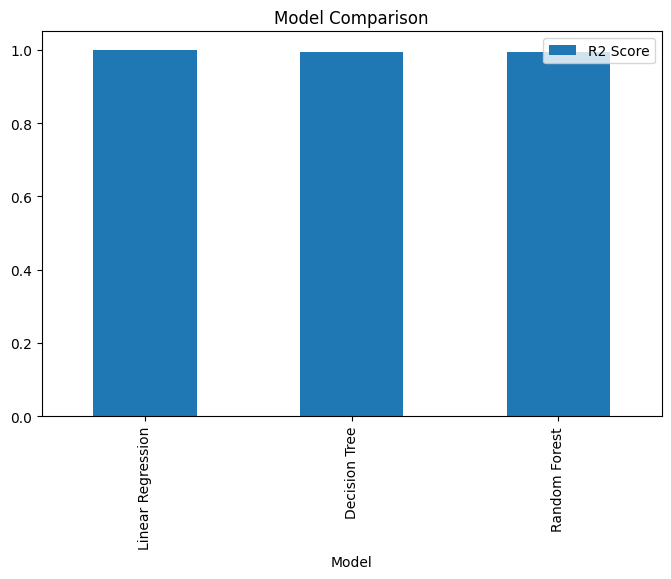

In [19]:
results.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    figsize=(8,5),
    title="Model Comparison"
)

plt.show()

In [20]:
prediction_df = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales (Linear Regression)": y_pred_lr,
    "Predicted Sales (Decision Tree)": y_pred_dt,
    "Predicted Sales (Random Forest)": y_pred_rf
})

prediction_df.head(10)

,Actual Sales,Predicted Sales (Linear Regression),Predicted Sales (Decision Tree),Predicted Sales (Random Forest)
65,864.80,864.80,863.85,857.8544
1096,68.00,68.00,68.00,68.0000
1027,75.59,75.59,65.60,77.7610
342,220.00,220.00,220.00,220.0000
557,157.50,157.50,157.50,157.4820
1054,72.00,72.00,72.00,71.7636
772,116.00,116.00,116.00,115.9500
316,236.40,236.40,229.60,233.7782
471,175.00,175.00,175.00,175.0000
367,204.00,204.00,204.00,203.2138


In [21]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Accessories': np.int64(0), 'Art & Sculpture': np.int64(1), 'Basket': np.int64(2), 'Christmas': np.int64(3), 'Easter': np.int64(4), 'Fair Trade Gifts': np.int64(5), 'Furniture': np.int64(6), 'Gift Baskets': np.int64(7), 'Home Decor': np.int64(8), 'Jewelry': np.int64(9), 'Kids': np.int64(10), 'Kitchen': np.int64(11), 'Music': np.int64(12), 'One-of-a-Kind': np.int64(13), 'Recycled Art': np.int64(14), 'Skin Care': np.int64(15), 'Soapstone': np.int64(16), 'Textiles': np.int64(17), nan: np.int64(18)}


In [22]:
new_data = pd.DataFrame({
    "Product Type":[0],      # Replace with encoded value
    "Net Quantity":[20],
    "Gross Sales":[5000],
    "Discounts":[-300],
    "Returns":[0]
})

prediction = rf.predict(new_data)

print("Predicted Total Net Sales:", prediction[0])

Predicted Total Net Sales: 3200.9065000000037


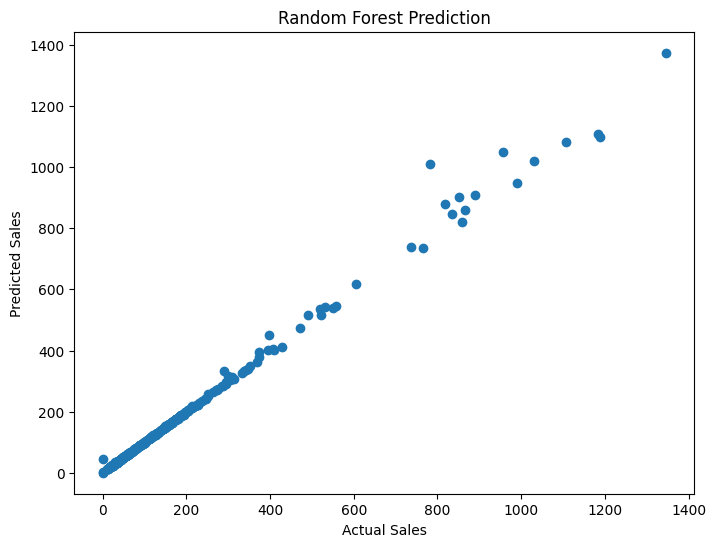

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest Prediction")

plt.show()

In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
2,Gross Sales,0.950993
4,Returns,0.027907
3,Discounts,0.019824
1,Net Quantity,0.000962
0,Product Type,0.000315


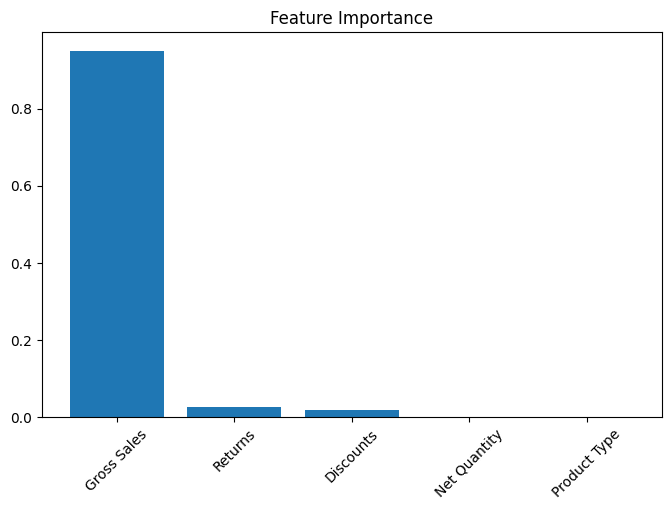

In [25]:
plt.figure(figsize=(8,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [26]:
from sklearn.metrics import mean_squared_error
import numpy as np

results["RMSE"] = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_dt)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf))
]

results

,Model,MAE,R2 Score,RMSE
0,Linear Regression,1.034540e-13,1.000000,1.342248e-13
1,Decision Tree,3.841690e+00,0.993616,1.635351e+01
2,Random Forest,3.897222e+00,0.993391,1.663887e+01


In [27]:
best_model = results.loc[results["R2 Score"].idxmax()]

print(best_model)

Model       Linear Regression
MAE                       0.0
R2 Score                  1.0
RMSE                      0.0
Name: 0, dtype: object


In [28]:
import joblib

joblib.dump(rf, "sales_forecasting_model.pkl")

['sales_forecasting_model.pkl']

In [29]:
from google.colab import files

files.download("sales_forecasting_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
prediction_df.to_csv("prediction_results.csv", index=False)

In [31]:
files.download("prediction_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
results.to_csv("model_comparison.csv", index=False)

files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>